In [3]:
# ===========================================================
# Single District Crop Recommendation (No Soil, Irrigation, Yield)
# District: Dakshina Kannada
# ===========================================================

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ----------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# ----------------------------------------------------
# 2. Filter only one district
# ----------------------------------------------------
district_name = "Dakshina Kannada"
df = df[df["district"] == district_name].reset_index(drop=True)

print(f"Rows for {district_name}: {len(df)}")

# ----------------------------------------------------
# 3. Drop unwanted columns
# ----------------------------------------------------
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 4. Select features and target
# ----------------------------------------------------
X = df.drop(["crop", "district"], axis=1)
y = df["crop"]

# ----------------------------------------------------
# 5. Encode categorical: season
# ----------------------------------------------------
encoder_season = LabelEncoder()
X["season"] = encoder_season.fit_transform(X["season"])

# Encode target crop
encoder_crop = LabelEncoder()
y = encoder_crop.fit_transform(y)

# ----------------------------------------------------
# 6. Scale numerical data
# ----------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------
# 7. Train-test split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# 8. Train model
# ----------------------------------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)
model.fit(X_train, y_train)

# ----------------------------------------------------
# 9. Accuracy
# ----------------------------------------------------
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)

print(f"✅ Accuracy ({district_name}): {acc*100:.2f}%")

# ----------------------------------------------------
# 10. Save model + encoders
# ----------------------------------------------------
joblib.dump(model, f"{district_name}_model.joblib")
joblib.dump(scaler, f"{district_name}_scaler.pkl")
joblib.dump(encoder_season, f"{district_name}_season_encoder.pkl")
joblib.dump(encoder_crop, f"{district_name}_crop_label_encoder.pkl")

print("✅ Model saved successfully!")

# ----------------------------------------------------
# 11. Prediction function
# ----------------------------------------------------
def predict_crop(season, rainfall, temp, humidity, pH, N, P, K):
    s = encoder_season.transform([season])[0]

    data = np.array([[s, rainfall, temp, humidity, pH, N, P, K]])
    data_scaled = scaler.transform(data)

    pred = model.predict(data_scaled)[0]
    return encoder_crop.inverse_transform([pred])[0]

# ----------------------------------------------------
# 12. Example Prediction
# ----------------------------------------------------
print("\nExample Prediction:")
print(predict_crop(
    season="Kharif",
    rainfall=320,
    temp=28,
    humidity=85,
    pH=6.5,
    N=90,
    P=40,
    K=40
))


Rows for Dakshina Kannada: 1587
✅ Accuracy (Dakshina Kannada): 92.45%
✅ Model saved successfully!

Example Prediction:
Paddy


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd

df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")
print(df.columns)


Index(['district', 'season', 'soil_type', 'rainfall_mm', 'avg_temp_C',
       'humidity_%', 'pH', 'N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'irrigation',
       'yield_kg_ha', 'crop'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   district     1587 non-null   object 
 1   season       1587 non-null   object 
 2   rainfall_mm  1587 non-null   float64
 3   avg_temp_C   1587 non-null   float64
 4   humidity_%   1587 non-null   float64
 5   pH           1587 non-null   float64
 6   N_kg_ha      1587 non-null   float64
 7   P_kg_ha      1587 non-null   float64
 8   K_kg_ha      1587 non-null   float64
 9   crop         1587 non-null   object 
dtypes: float64(7), object(3)
memory usage: 124.1+ KB


In [5]:
df.shape

(1587, 10)

In [6]:
# ===========================================================
# MULTI-MODEL CROP RECOMMENDATION (Single District)
# NO Soil, NO Irrigation, NO Yield
# Models: RF, XGBoost, LightGBM, CatBoost, MLP
# Auto-select best model
# ===========================================================

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier


# ----------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# ----------------------------------------------------
# 2. Filter only one district
# ----------------------------------------------------
district_name = "Dakshina Kannada"
df = df[df["district"] == district_name].reset_index(drop=True)

print(f"Rows for {district_name}: {len(df)}")

# ----------------------------------------------------
# 3. Drop unwanted columns
# ----------------------------------------------------
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 4. Prepare X and y
# ----------------------------------------------------
X = df.drop(["crop", "district"], axis=1)
y = df["crop"]

# Encode only "season"
encoder_season = LabelEncoder()
X["season"] = encoder_season.fit_transform(X["season"])

# Encode crop label
encoder_crop = LabelEncoder()
y = encoder_crop.fit_transform(y)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# 5. Define multiple models
# ----------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=0
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=500
    )
}

# ----------------------------------------------------
# 6. Train and evaluate each model
# ----------------------------------------------------
model_accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    model_accuracies[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")

# ----------------------------------------------------
# 7. Select best model
# ----------------------------------------------------
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = models[best_model_name]

print("\n===================================")
print(f"🏆 Best Model = {best_model_name}")
print(f"🏆 Best Accuracy = {model_accuracies[best_model_name]*100:.2f}%")
print("===================================\n")

# ----------------------------------------------------
# 8. Save best model + encoders
# ----------------------------------------------------
joblib.dump(best_model, f"BEST_MODEL_{district_name}.joblib")
joblib.dump(scaler, f"{district_name}_scaler.pkl")
joblib.dump(encoder_season, f"{district_name}_season_encoder.pkl")
joblib.dump(encoder_crop, f"{district_name}_crop_encoder.pkl")
joblib.dump(model_accuracies, f"{district_name}_model_scores.json")

print("✅ Best model + encoders saved!")

# ----------------------------------------------------
# 9. Final Prediction Function
# ----------------------------------------------------
def predict_crop(season, rainfall, temp, humidity, pH, N, P, K):

    s = encoder_season.transform([season])[0]

    data = np.array([[s, rainfall, temp, humidity, pH, N, P, K]])
    scaled = scaler.transform(data)

    pred = best_model.predict(scaled)[0]
    return encoder_crop.inverse_transform([pred])[0]


# Example
print("Example Prediction:")
print(predict_crop("Kharif", 300, 28, 85, 6.5, 80, 40, 40))


Rows for Dakshina Kannada: 1587
RandomForest Accuracy: 92.45%
XGBoost Accuracy: 92.45%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000451 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1269, number of used features: 8
[LightGBM] [Info] Start training from score -1.832778
[LightGBM] [Info] Start training from score -1.847667
[LightGBM] [Info] Start training from score -1.743307
[LightGBM] [Info] Start training from score -1.752357
[LightGBM] [Info] Start training from score -1.752357
[LightGBM] [Info] Start training from score -1.827864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 91.82%
CatBoost Accuracy: 92.77%
MLP Accuracy: 91.51%

🏆 Best Model = CatBoost
🏆 Best Accuracy = 92.77%

✅ Best model + encoders saved!
Example Prediction:
Paddy


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
# ===========================================================
# AUTO-TRAIN 31 DISTRICT MODELS (RandomForest + XGBoost)
# Removes Soil, Irrigation, Yield
# Saves BEST model per district
# ===========================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# ----------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# ----------------------------------------------------
# 2. Remove unwanted columns
# ----------------------------------------------------
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 3. Create model folder
# ----------------------------------------------------
os.makedirs("models", exist_ok=True)

# ----------------------------------------------------
# 4. Get district list
# ----------------------------------------------------
districts = df["district"].unique()
print("Total districts:", len(districts))
print(districts)

# To store accuracy results
results = {}

# ----------------------------------------------------
# 5. Train model for each district
# ----------------------------------------------------
for district_name in districts:
    print("\n==================================================")
    print(f"TRAINING FOR DISTRICT: {district_name}")
    print("==================================================")

    # Filter district data
    ddf = df[df["district"] == district_name].reset_index(drop=True)

    if len(ddf) < 30:
        print(f"⚠ Skipping {district_name} (too little data)")
        continue

    # Prepare X and y
    X = ddf.drop(["crop", "district"], axis=1)
    y = ddf["crop"]

    # Encode season
    encoder_season = LabelEncoder()
    X["season"] = encoder_season.fit_transform(X["season"])

    # Encode label (crop)
    encoder_crop = LabelEncoder()
    y = encoder_crop.fit_transform(y)

    # Scale numeric features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ----------------------------------------------------
    # MODELS TO COMPARE
    # ----------------------------------------------------
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=20, random_state=42
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.8,
            eval_metric="mlogloss"
        )
    }

    model_scores = {}

    # Train each model
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        model_scores[name] = acc
        print(f"{name} Accuracy = {acc*100:.2f}%")

    # ----------------------------------------------------
    # Select the BEST model
    # ----------------------------------------------------
    best_model_name = max(model_scores, key=model_scores.get)
    best_model = models[best_model_name]

    print(f"\n🏆 BEST MODEL for {district_name}: {best_model_name}")
    print(f"🏆 Accuracy: {model_scores[best_model_name]*100:.2f}%")

    # Save accuracy
    results[district_name] = {
        "best_model": best_model_name,
        "accuracy": model_scores[best_model_name]
    }

    # ----------------------------------------------------
    # SAVE THE BEST MODEL + ENCODERS
    # ----------------------------------------------------
    joblib.dump(best_model, f"models/{district_name}_BEST_MODEL.joblib")
    joblib.dump(scaler, f"models/{district_name}_scaler.pkl")
    joblib.dump(encoder_season, f"models/{district_name}_season_encoder.pkl")
    joblib.dump(encoder_crop, f"models/{district_name}_crop_encoder.pkl")

    print(f"✔ Saved BEST model for {district_name}")

# ----------------------------------------------------
# 6. Save accuracy summary
# ----------------------------------------------------
joblib.dump(results, "models/ALL_DISTRICT_ACCURACIES.pkl")

print("\n==================================================")
print("🎉 COMPLETED MODEL TRAINING FOR ALL DISTRICTS")
print("==================================================")
print(results)


Total districts: 31
['Mandya' 'Chikkaballapur' 'Vijayapura' 'Bagalkote' 'Kodagu' 'Tumakuru'
 'Gadag' 'Shivamogga' 'Davanagere' 'Ramanagara' 'Dharwad' 'Koppal'
 'Ballari' 'Belagavi' 'Hassan' 'Mysuru' 'Yadgir' 'Dakshina Kannada'
 'Chikballapur' 'Bengaluru Rural' 'Uttara Kannada' 'Kalaburagi'
 'Chamarajanagar' 'Haveri' 'Udupi' 'Kolar' 'Bengaluru Urban' 'Bidar'
 'Chitradurga' 'Raichur' 'Chikkamagaluru']

TRAINING FOR DISTRICT: Mandya
RandomForest Accuracy = 83.33%
XGBoost Accuracy = 83.63%

🏆 BEST MODEL for Mandya: XGBoost
🏆 Accuracy: 83.63%
✔ Saved BEST model for Mandya

TRAINING FOR DISTRICT: Chikkaballapur
RandomForest Accuracy = 76.04%
XGBoost Accuracy = 75.72%

🏆 BEST MODEL for Chikkaballapur: RandomForest
🏆 Accuracy: 76.04%
✔ Saved BEST model for Chikkaballapur

TRAINING FOR DISTRICT: Vijayapura
RandomForest Accuracy = 91.51%
XGBoost Accuracy = 90.88%

🏆 BEST MODEL for Vijayapura: RandomForest
🏆 Accuracy: 91.51%
✔ Saved BEST model for Vijayapura

TRAINING FOR DISTRICT: Bagalkote
Rand

In [9]:
# ===========================================================
# OPTION C: FULL (ALL MODELS + ENSEMBLES) - 31 Districts Auto-Train
# Uses combined dataset: /mnt/data/Karnataka_realistic_50k_reordered.csv
# Drops: soil_type, irrigation, yield_kg_ha
# Trains many models per district, picks & saves BEST model per district
# ===========================================================

import os
import json
import joblib
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# models
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# tree boosters
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ---------------------------
# Config
# ---------------------------
DATA_PATH = "Karnataka_realistic_50k_reordered.csv"
OUTPUT_DIR = "models"
MIN_ROWS_PER_DISTRICT = 30   # skip districts with fewer rows than this
TEST_SIZE = 0.2
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
warnings.filterwarnings("ignore")

# ---------------------------
# Load and preprocess dataset
# ---------------------------
df = pd.read_csv(DATA_PATH)
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())

# Drop unwanted columns if present
drop_cols = [c for c in ["soil_type", "irrigation", "yield_kg_ha"] if c in df.columns]
if drop_cols:
    df = df.drop(drop_cols, axis=1)
    print("Dropped columns:", drop_cols)

# We'll remove rows with missing values in required columns
required_cols = ["district", "season", "rainfall_mm", "avg_temp_C",
                 "humidity_%", "pH", "N_kg_ha", "P_kg_ha", "K_kg_ha", "crop"]
missing_required = df[required_cols].isnull().any(axis=1).sum()
if missing_required:
    print(f"Removing {missing_required} rows with missing required fields.")
    df = df.dropna(subset=required_cols).reset_index(drop=True)

districts = df["district"].unique()
print("Found districts:", len(districts))

# Summary containers
all_results = {}   # district -> model -> accuracy

# ---------------------------
# Loop districts
# ---------------------------
for district_name in districts:
    print("\n" + "="*70)
    print(f"District: {district_name}")
    ddf = df[df["district"] == district_name].reset_index(drop=True)
    n_rows = len(ddf)
    print(f"Rows for {district_name}: {n_rows}")

    if n_rows < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping {district_name}: only {n_rows} rows (MIN required: {MIN_ROWS_PER_DISTRICT})")
        all_results[district_name] = {"skipped": True, "rows": n_rows}
        continue

    # Features & label
    X = ddf.drop(["crop", "district"], axis=1).copy()
    y = ddf["crop"].copy()

    # Encode season (single categorical)
    season_le = LabelEncoder()
    X["season"] = season_le.fit_transform(X["season"])

    # Label encode target crop
    crop_le = LabelEncoder()
    y_enc = crop_le.fit_transform(y)

    # Train-test split (stratify by y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
    )

    # Scale numeric features (season is already numeric after encoding)
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ---------------------------
    # Define models
    # ---------------------------
    # We wrap models where needed. All models receive scaled input.
    models = OrderedDict()

    # Tree-based and boosters (do not require probability wrapper)
    models["RandomForest"] = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=RANDOM_STATE)
    models["ExtraTrees"] = ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE)
    models["GradientBoosting"] = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)

    # Boosters
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric="mlogloss", random_state=RANDOM_STATE
    )
    models["LightGBM"] = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)
    models["CatBoost"] = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0, random_state=RANDOM_STATE)

    # Linear / simple models
    models["LogisticRegression"] = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    models["SVM"] = SVC(probability=True, random_state=RANDOM_STATE)   # probability=True for Voting
    models["KNN"] = KNeighborsClassifier(n_neighbors=7)
    models["MLP"] = MLPClassifier(hidden_layer_sizes=(128,64), activation="relu", max_iter=500, random_state=RANDOM_STATE)
    models["GaussianNB"] = GaussianNB()

    # ---------------------------
    # Train & evaluate all base models
    # ---------------------------
    district_scores = {}
    trained_models = {}

    for name, model in models.items():
        try:
            # fit on scaled data for all models (trees could work without scaling; using scaled input is OK)
            model.fit(X_train_s, y_train)
            y_pred = model.predict(X_test_s)
            acc = accuracy_score(y_test, y_pred)
            district_scores[name] = float(acc)
            trained_models[name] = model
            print(f"{name}: {acc*100:.2f}%")
        except Exception as e:
            district_scores[name] = None
            print(f"Failed {name}: {e}")

    # ---------------------------
    # Voting Classifier (soft if possible)
    # ---------------------------
    try:
        # choose subset of models that were trained successfully and support predict_proba
        voting_estimators = [(n, m) for n, m in trained_models.items()]
        # For VotingClassifier in sklearn we pass list of (name, estimator)
        voting = VotingClassifier(estimators=voting_estimators, voting="soft", n_jobs=-1)
        voting.fit(X_train_s, y_train)
        yv = voting.predict(X_test_s)
        acc_v = accuracy_score(y_test, yv)
        district_scores["Voting"] = float(acc_v)
        trained_models["Voting"] = voting
        print(f"Voting (soft) : {acc_v*100:.2f}%")
    except Exception as e:
        # fallback: try hard voting with classifiers that don't support prob
        try:
            voting_hard = VotingClassifier(estimators=[(n, m) for n,m in trained_models.items()], voting="hard", n_jobs=-1)
            voting_hard.fit(X_train_s, y_train)
            yv = voting_hard.predict(X_test_s)
            acc_v = accuracy_score(y_test, yv)
            district_scores["Voting_hard"] = float(acc_v)
            trained_models["Voting_hard"] = voting_hard
            print(f"Voting (hard): {acc_v*100:.2f}%")
        except Exception as e2:
            print("Voting failed:", e, e2)

    # ---------------------------
    # Stacking Classifier (meta: LogisticRegression)
    # ---------------------------
    try:
        # Use a subset of strong base models to avoid heavy meta-train time
        # prefer tree boosters + rf + lgbm + xgb + catboost if present
        preferred = ["RandomForest", "XGBoost", "LightGBM", "CatBoost", "ExtraTrees"]
        stack_estimators = [(n, trained_models[n]) for n in preferred if n in trained_models]
        if stack_estimators:
            stacking = StackingClassifier(
                estimators=stack_estimators,
                final_estimator=LogisticRegression(max_iter=1000),
                cv=3,
                n_jobs=-1,
                passthrough=False
            )
            stacking.fit(X_train_s, y_train)
            ys = stacking.predict(X_test_s)
            acc_s = accuracy_score(y_test, ys)
            district_scores["Stacking"] = float(acc_s)
            trained_models["Stacking"] = stacking
            print(f"Stacking : {acc_s*100:.2f}%")
        else:
            print("No estimators available for stacking.")
    except Exception as e:
        print("Stacking failed:", e)

    # ---------------------------
    # Choose Best Model
    # ---------------------------
    # Filter out None results
    valid_scores = {k: v for k, v in district_scores.items() if v is not None}
    if not valid_scores:
        print("No valid models for this district.")
        all_results[district_name] = {"skipped": False, "rows": n_rows, "scores": district_scores}
        continue

    best_model_name = max(valid_scores, key=valid_scores.get)
    best_acc = valid_scores[best_model_name]
    best_model = trained_models[best_model_name]

    print(f"\nBEST for {district_name} -> {best_model_name} : {best_acc*100:.2f}%")

    # ---------------------------
    # Save best model and artifacts
    # ---------------------------
    safe_name = district_name.replace(" ", "_").replace("/", "_")
    model_file = os.path.join(OUTPUT_DIR, f"{safe_name}_BEST_MODEL.joblib")
    scaler_file = os.path.join(OUTPUT_DIR, f"{safe_name}_scaler.pkl")
    season_encoder_file = os.path.join(OUTPUT_DIR, f"{safe_name}_season_encoder.pkl")
    crop_encoder_file = os.path.join(OUTPUT_DIR, f"{safe_name}_crop_encoder.pkl")
    scores_file = os.path.join(OUTPUT_DIR, f"{safe_name}_model_scores.json")

    joblib.dump(best_model, model_file)
    joblib.dump(scaler, scaler_file)
    joblib.dump(season_le, season_encoder_file)
    joblib.dump(crop_le, crop_encoder_file)

    # Save per-model scores for this district
    with open(scores_file, "w") as f:
        json.dump(district_scores, f, indent=2)

    all_results[district_name] = {
        "rows": n_rows,
        "best_model": best_model_name,
        "best_accuracy": best_acc,
        "scores": district_scores
    }

    print(f"Saved best model and artifacts for {district_name} -> {model_file}")

# ---------------------------
# Save summary of everything
# ---------------------------
summary_file = os.path.join(OUTPUT_DIR, "ALL_DISTRICTS_SUMMARY.json")
with open(summary_file, "w") as f:
    json.dump(all_results, f, indent=2)

# Also create a CSV summary for easy viewing
rows = []
for d, info in all_results.items():
    if isinstance(info, dict) and "scores" in info:
        for model_name, score in info["scores"].items():
            rows.append({
                "district": d,
                "rows": info.get("rows"),
                "model": model_name,
                "accuracy": score if score is not None else ""
            })
    else:
        rows.append({"district": d, "rows": info.get("rows") if isinstance(info, dict) else "", "model": "SKIPPED", "accuracy": ""})

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "ALL_DISTRICTS_MODEL_SUMMARY.csv"), index=False)

print("\nAll done. Summary saved to:", summary_file)
print("CSV summary saved to:", os.path.join(OUTPUT_DIR, "ALL_DISTRICTS_MODEL_SUMMARY.csv"))


Total rows: 50000
Columns: ['district', 'season', 'soil_type', 'rainfall_mm', 'avg_temp_C', 'humidity_%', 'pH', 'N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'irrigation', 'yield_kg_ha', 'crop']
Dropped columns: ['soil_type', 'irrigation', 'yield_kg_ha']
Found districts: 31

District: Mandya
Rows for Mandya: 1679
RandomForest: 84.52%
ExtraTrees: 84.82%
GradientBoosting: 84.82%
XGBoost: 83.93%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 8
[LightGBM] [Info] Start training from score -1.604239
[LightGBM] [Info] Start training from score -1.626712
[LightGBM] [Info] Start training from score -1.649702
[LightGBM] [Info] Start training from score -1.604239
[LightGBM] [Info] Start training from score -1.564307
[LightGBM] [Warning] No further splits with positive gain, b

Selected District Count: 15


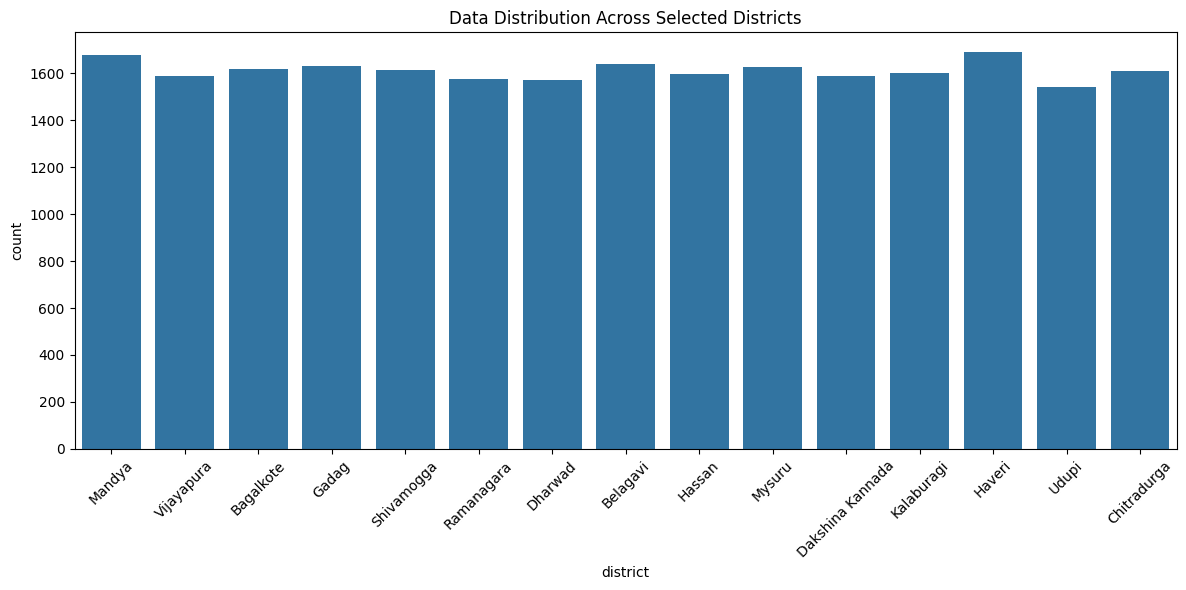

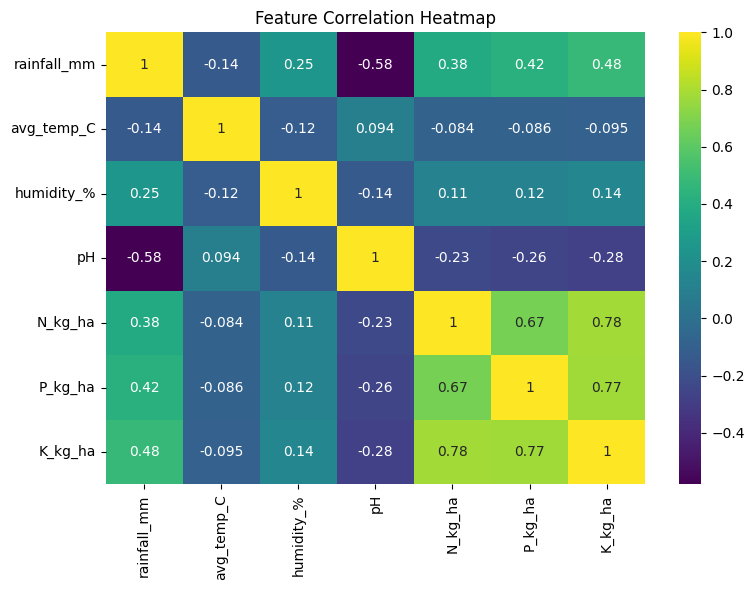


==================== Mandya ====================
RandomForest → 83.33%


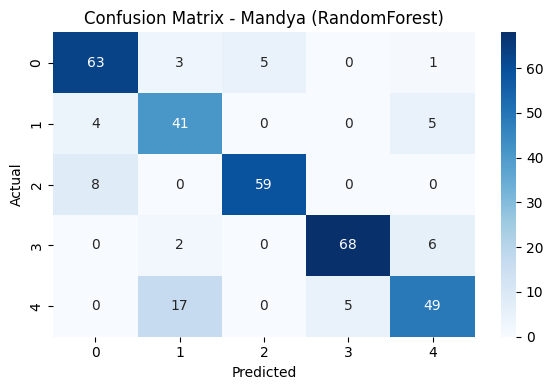

XGBoost → 83.63%


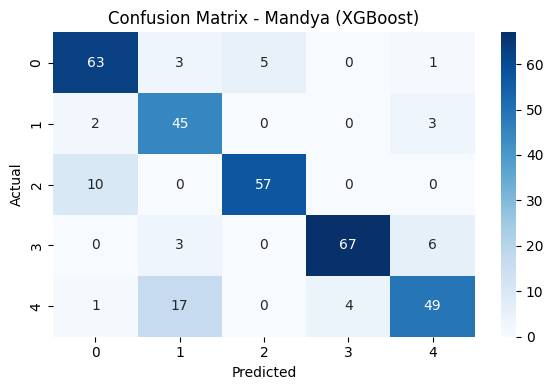

🏆 Best Model for Mandya: XGBoost

==================== Vijayapura ====================
RandomForest → 91.51%


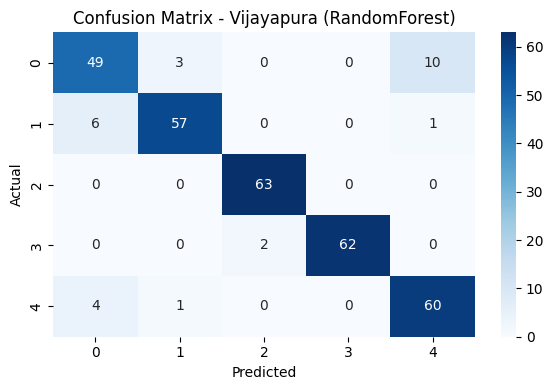

XGBoost → 90.88%


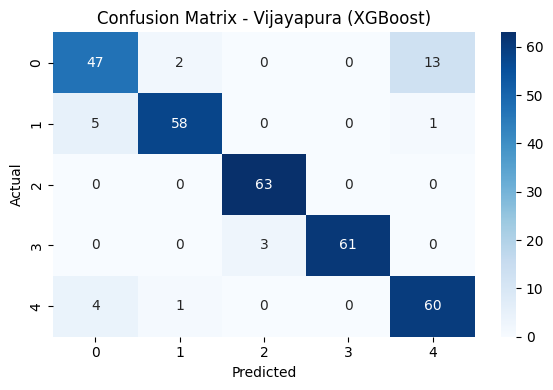

🏆 Best Model for Vijayapura: RandomForest

==================== Bagalkote ====================
RandomForest → 84.88%


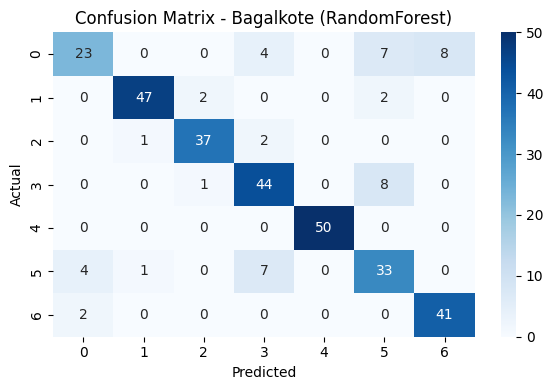

XGBoost → 84.88%


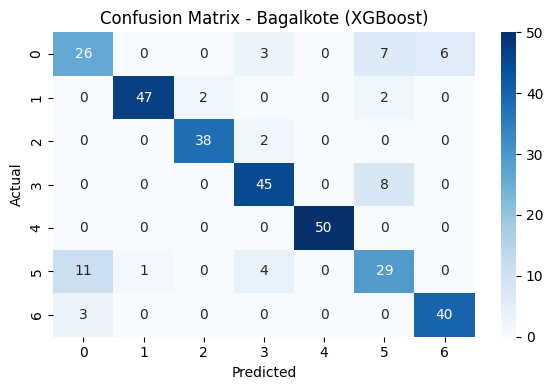

🏆 Best Model for Bagalkote: RandomForest

==================== Gadag ====================
RandomForest → 81.65%


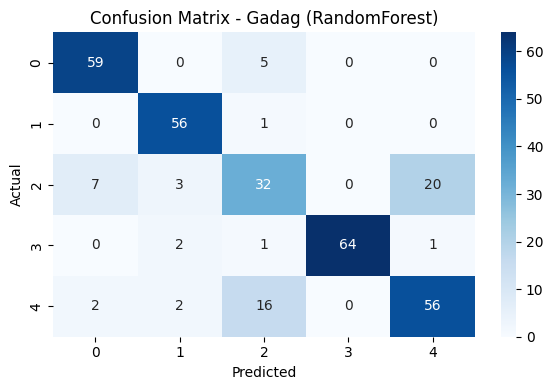

XGBoost → 80.12%


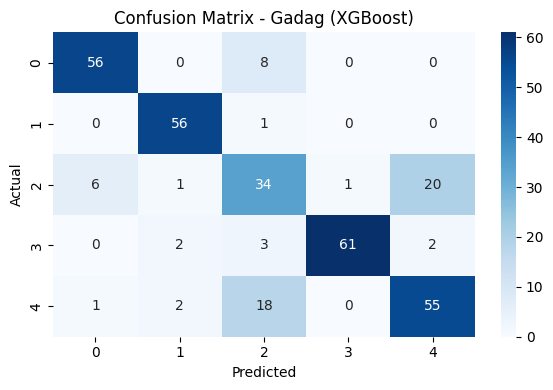

🏆 Best Model for Gadag: RandomForest

==================== Shivamogga ====================
RandomForest → 89.78%


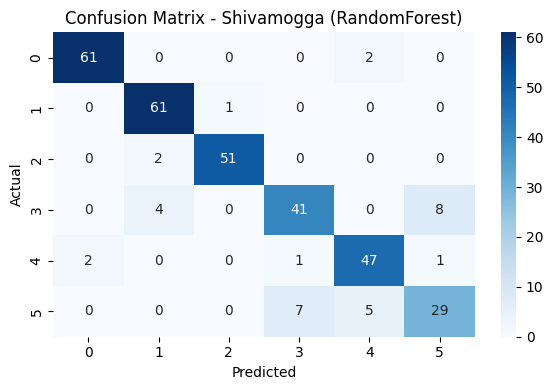

XGBoost → 89.47%


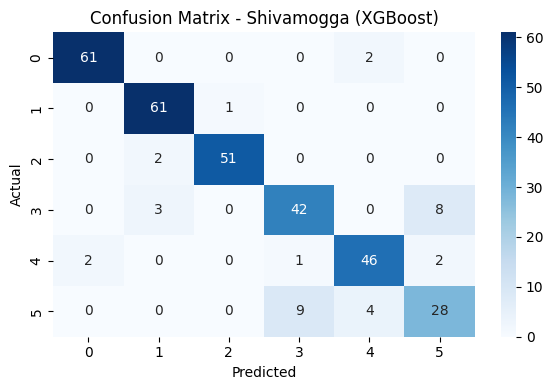

🏆 Best Model for Shivamogga: RandomForest

==================== Ramanagara ====================
RandomForest → 88.57%


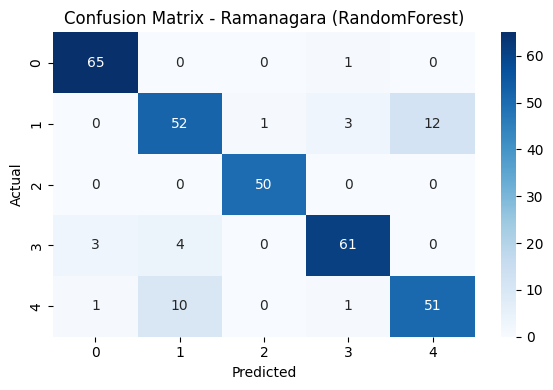

XGBoost → 86.98%


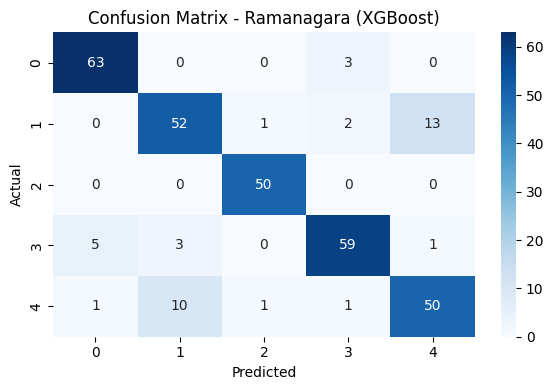

🏆 Best Model for Ramanagara: RandomForest

==================== Dharwad ====================
RandomForest → 90.45%


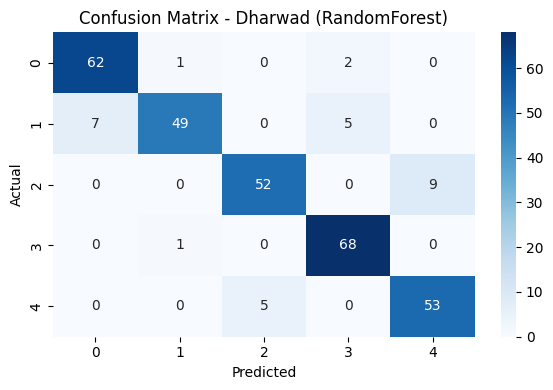

XGBoost → 90.76%


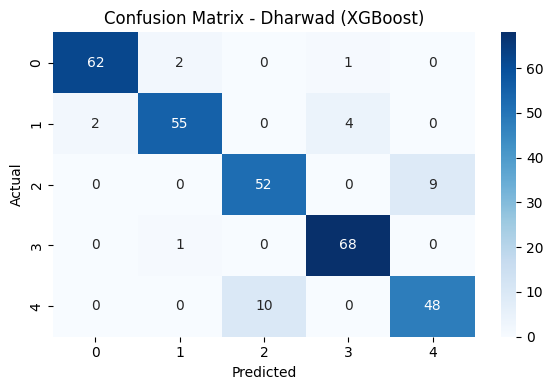

🏆 Best Model for Dharwad: XGBoost

==================== Belagavi ====================
RandomForest → 93.29%


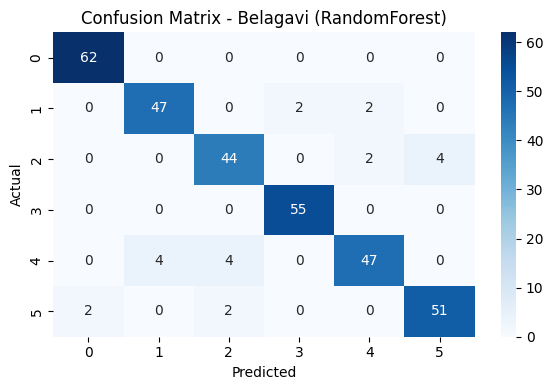

XGBoost → 94.82%


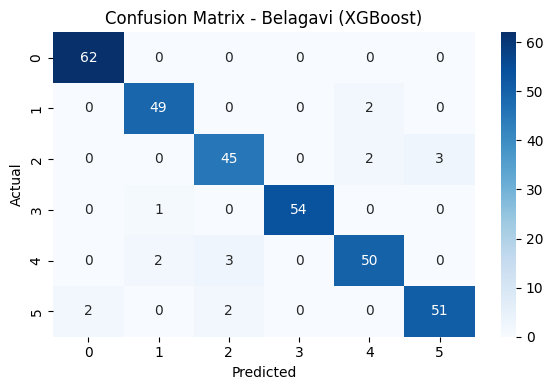

🏆 Best Model for Belagavi: XGBoost

==================== Hassan ====================
RandomForest → 85.62%


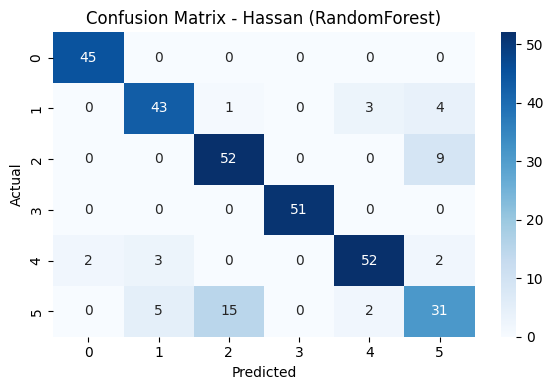

XGBoost → 83.75%


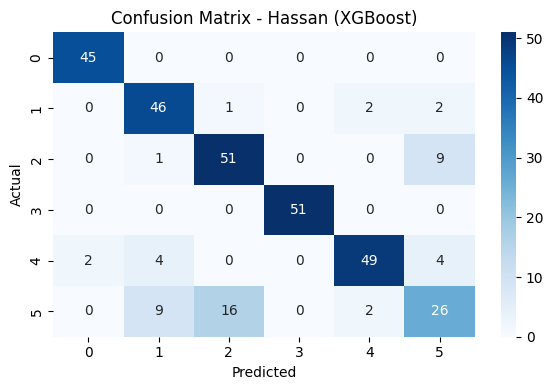

🏆 Best Model for Hassan: RandomForest

==================== Mysuru ====================
RandomForest → 86.77%


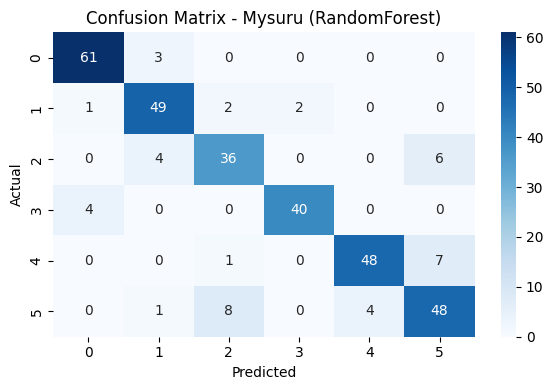

XGBoost → 84.62%


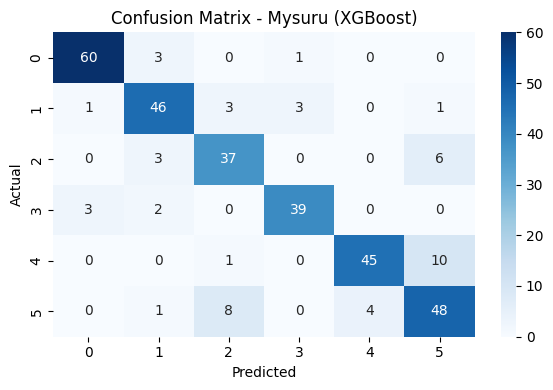

🏆 Best Model for Mysuru: RandomForest

==================== Dakshina Kannada ====================
RandomForest → 92.45%


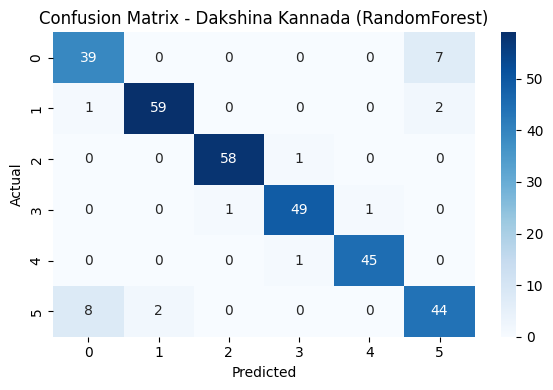

XGBoost → 92.45%


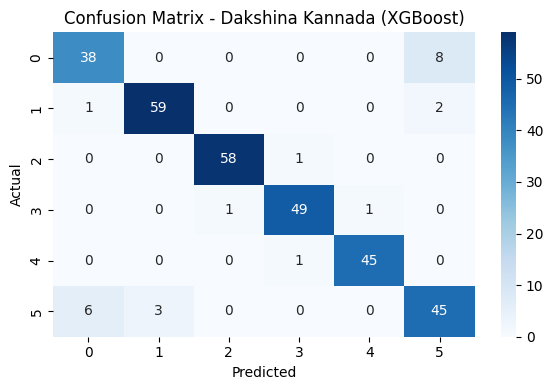

🏆 Best Model for Dakshina Kannada: RandomForest

==================== Kalaburagi ====================
RandomForest → 89.10%


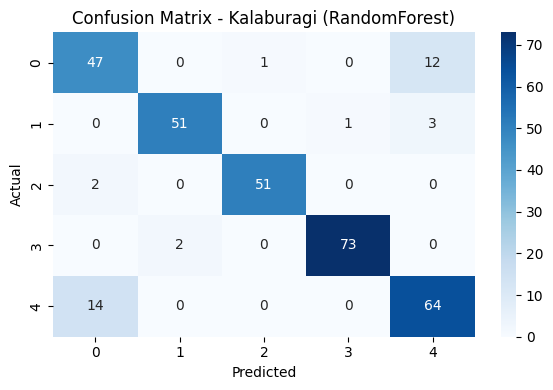

XGBoost → 88.79%


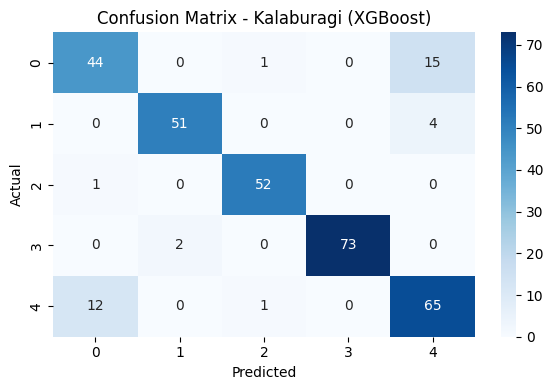

🏆 Best Model for Kalaburagi: RandomForest

==================== Haveri ====================
RandomForest → 90.53%


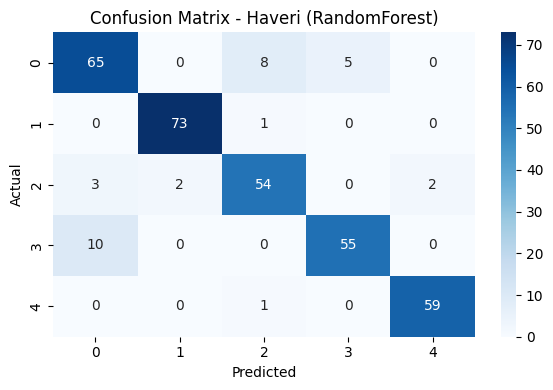

XGBoost → 88.76%


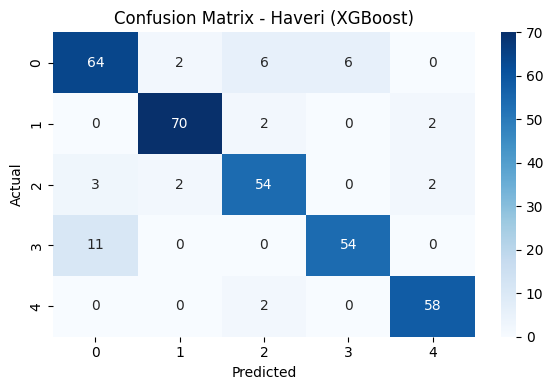

🏆 Best Model for Haveri: RandomForest

==================== Udupi ====================
RandomForest → 96.44%


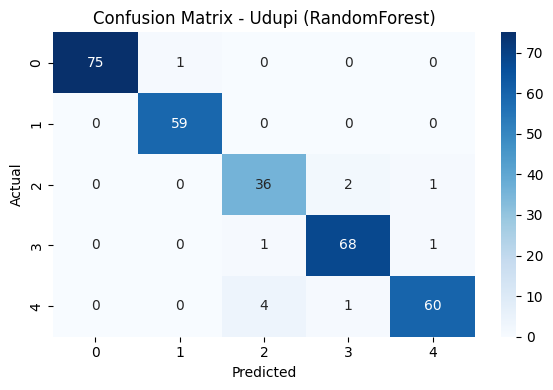

XGBoost → 97.09%


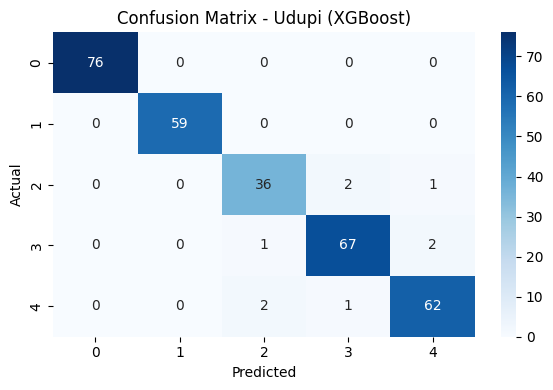

🏆 Best Model for Udupi: XGBoost

==================== Chitradurga ====================
RandomForest → 92.55%


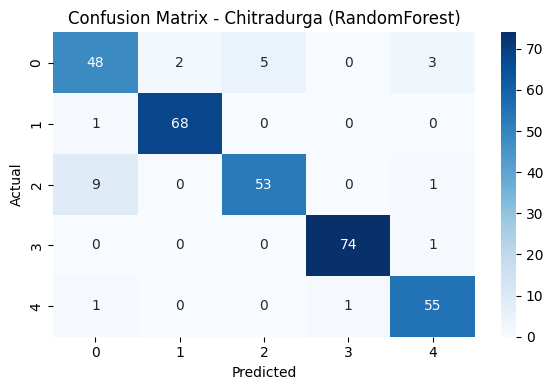

XGBoost → 90.99%


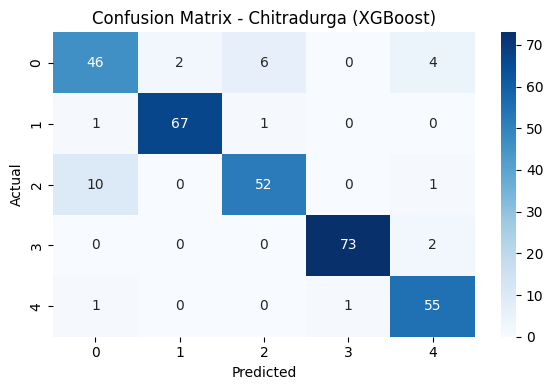

🏆 Best Model for Chitradurga: RandomForest

🎉 Training Complete For Selected 15 Districts!
{'Mandya': 0.8363095238095238, 'Vijayapura': 0.9150943396226415, 'Bagalkote': 0.8487654320987654, 'Gadag': 0.8165137614678899, 'Shivamogga': 0.8978328173374613, 'Ramanagara': 0.8857142857142857, 'Dharwad': 0.9076433121019108, 'Belagavi': 0.948170731707317, 'Hassan': 0.85625, 'Mysuru': 0.8676923076923077, 'Dakshina Kannada': 0.9245283018867925, 'Kalaburagi': 0.8909657320872274, 'Haveri': 0.9053254437869822, 'Udupi': 0.970873786407767, 'Chitradurga': 0.9254658385093167}


In [3]:
# ===========================================================
# TRAIN MODELS FOR SELECTED 15 DISTRICTS ONLY
# Models: RandomForest + XGBoost
# Saves Confusion Matrices + Accuracy + Trained Models
# Shows Visualizations on Screen
# ===========================================================

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ----------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# Remove unwanted columns
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 2. Select Only Required Districts
# ----------------------------------------------------
selected_districts = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag", "Shivamogga", "Ramanagara",
    "Dharwad", "Belagavi", "Hassan", "Mysuru", "Dakshina Kannada",
    "Kalaburagi", "Haveri", "Udupi", "Chitradurga"
]

df = df[df["district"].isin(selected_districts)].reset_index(drop=True)
print("Selected District Count:", df["district"].nunique())

# ----------------------------------------------------
# 3. Visualization: District Sample Count
# ----------------------------------------------------
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="district")
plt.xticks(rotation=45)
plt.title("Data Distribution Across Selected Districts")
plt.tight_layout()
plt.savefig("models_15_district_distribution.png")
plt.show()     # SHOW ON SCREEN
plt.close()

# ----------------------------------------------------
# 4. Visualization: Feature Correlation Heatmap
# ----------------------------------------------------
numeric_cols = ["rainfall_mm", "avg_temp_C", "humidity_%", "pH",
                "N_kg_ha", "P_kg_ha", "K_kg_ha"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="viridis")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("models_15_correlation_heatmap.png")
plt.show()    # SHOW ON SCREEN
plt.close()

# ----------------------------------------------------
# 5. Create model folder
# ----------------------------------------------------
os.makedirs("models_15", exist_ok=True)

results = {}

# ----------------------------------------------------
# 6. Train Model For Each Selected District
# ----------------------------------------------------
for district_name in selected_districts:
    
    print(f"\n==================== {district_name} ====================")

    ddf = df[df["district"] == district_name].reset_index(drop=True)

    if len(ddf) < 30:
        print(f"⚠ Not enough data for {district_name}, skipping...")
        continue

    X = ddf.drop(["crop", "district"], axis=1)
    y = ddf["crop"]

    # Encode season
    le_season = LabelEncoder()
    X["season"] = le_season.fit_transform(X["season"])

    # Encode crop label
    le_crop = LabelEncoder()
    y = le_crop.fit_transform(y)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ---------------------------------------------
    # Models
    # ---------------------------------------------
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=20, random_state=42
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.8,
            eval_metric="mlogloss"
        )
    }

    scores = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        scores[name] = acc
        print(f"{name} → {acc*100:.2f}%")

        # -----------------------------
        # Confusion Matrix
        # -----------------------------
        cm = confusion_matrix(y_test, pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {district_name} ({name})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.savefig(f"models_15/{district_name}_{name}_confusion_matrix.png")
        plt.show()   # SHOW ON SCREEN
        plt.close()

    # ---------------------------------------------
    # Select Best Model
    # ---------------------------------------------
    best_name = max(scores, key=scores.get)
    best_model = models[best_name]

    print(f"🏆 Best Model for {district_name}: {best_name}")

    results[district_name] = scores[best_name]

    # ---------------------------------------------
    # Save Files
    # ---------------------------------------------
    joblib.dump(best_model, f"models_15/{district_name}_model.joblib")
    joblib.dump(scaler, f"models_15/{district_name}_scaler.pkl")
    joblib.dump(le_season, f"models_15/{district_name}_season_encoder.pkl")
    joblib.dump(le_crop, f"models_15/{district_name}_crop_encoder.pkl")

# Save master results
joblib.dump(results, "models_15/district_accuracies.pkl")

print("\n🎉 Training Complete For Selected 15 Districts!")
print(results)


In [6]:
# ================================================================
# TRAIN ONE COMBINED MODEL FOR ALL 15 DISTRICTS
# Models: RandomForest + XGBoost (choose best)
# Handles: District + Season + Weather + Soil features
# Saves: Best Model, Scaler, Encoders, Accuracy
# ================================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ----------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# Remove unwanted columns
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 2. Filter Only Required 15 Districts
# ----------------------------------------------------
selected_districts = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag", "Shivamogga", "Ramanagara",
    "Dharwad", "Belagavi", "Hassan", "Mysuru", "Dakshina Kannada",
    "Kalaburagi", "Haveri", "Udupi", "Chitradurga"
]

df = df[df["district"].isin(selected_districts)].reset_index(drop=True)
print("Final dataset size:", len(df))

# ----------------------------------------------------
# 3. Encode district and season
# ----------------------------------------------------
le_district = LabelEncoder()
df["district"] = le_district.fit_transform(df["district"])

le_season = LabelEncoder()
df["season"] = le_season.fit_transform(df["season"])

# Encode crop label
le_crop = LabelEncoder()
df["crop"] = le_crop.fit_transform(df["crop"])

# ----------------------------------------------------
# 4. Split features and target
# ----------------------------------------------------
X = df.drop("crop", axis=1)
y = df["crop"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------
# 5. Train-test split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# 6. Models to Compare
# ----------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=24, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="mlogloss"
    )
}

scores = {}

# ----------------------------------------------------
# 7. Train + Evaluate Models
# ----------------------------------------------------
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    scores[name] = acc
    print(f"{name} Accuracy = {acc*100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"combined_confusion_matrix_{name}.png")
    plt.close()

# ----------------------------------------------------
# 8. Select Best Model
# ----------------------------------------------------
best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

print("\n========================================")
print(f"🏆 Best Combined Model: {best_model_name}")
print(f"🏆 Accuracy: {scores[best_model_name]*100:.2f}%")
print("========================================\n")

# ----------------------------------------------------
# 9. Save Model + Encoders + Scaler
# ----------------------------------------------------
os.makedirs("combined_model", exist_ok=True)

joblib.dump(best_model, "combined_model/best_combined_model.joblib")
joblib.dump(scaler, "combined_model/scaler.pkl")
joblib.dump(le_district, "combined_model/district_encoder.pkl")
joblib.dump(le_season, "combined_model/season_encoder.pkl")
joblib.dump(le_crop, "combined_model/crop_encoder.pkl")
joblib.dump(scores, "combined_model/model_accuracy.pkl")

print("🎉 Saved all model files successfully!")


Final dataset size: 24163

Training RandomForest...
RandomForest Accuracy = 88.60%

Training XGBoost...
XGBoost Accuracy = 88.56%

🏆 Best Combined Model: RandomForest
🏆 Accuracy: 88.60%

🎉 Saved all model files successfully!


Final dataset size: 24163


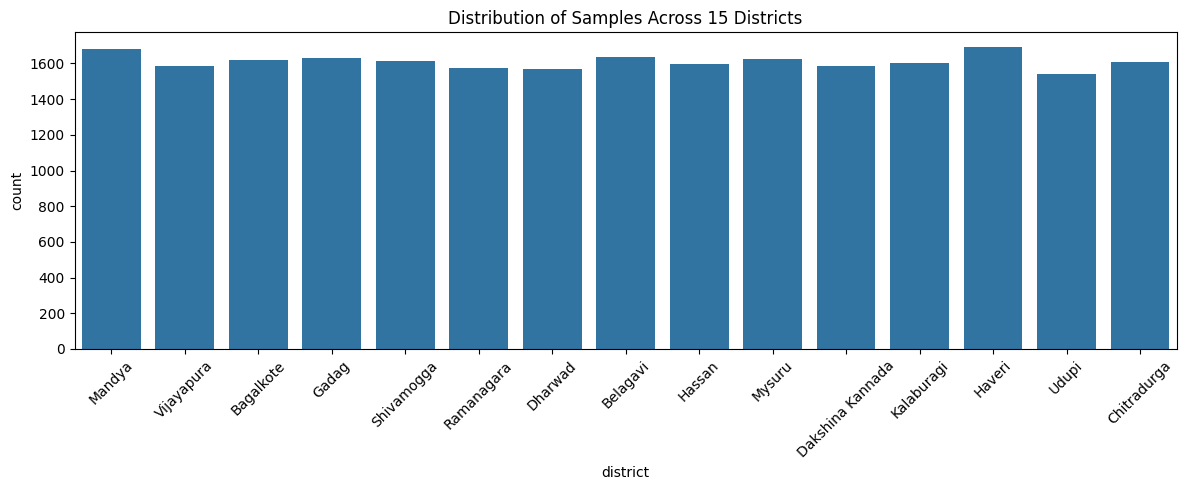

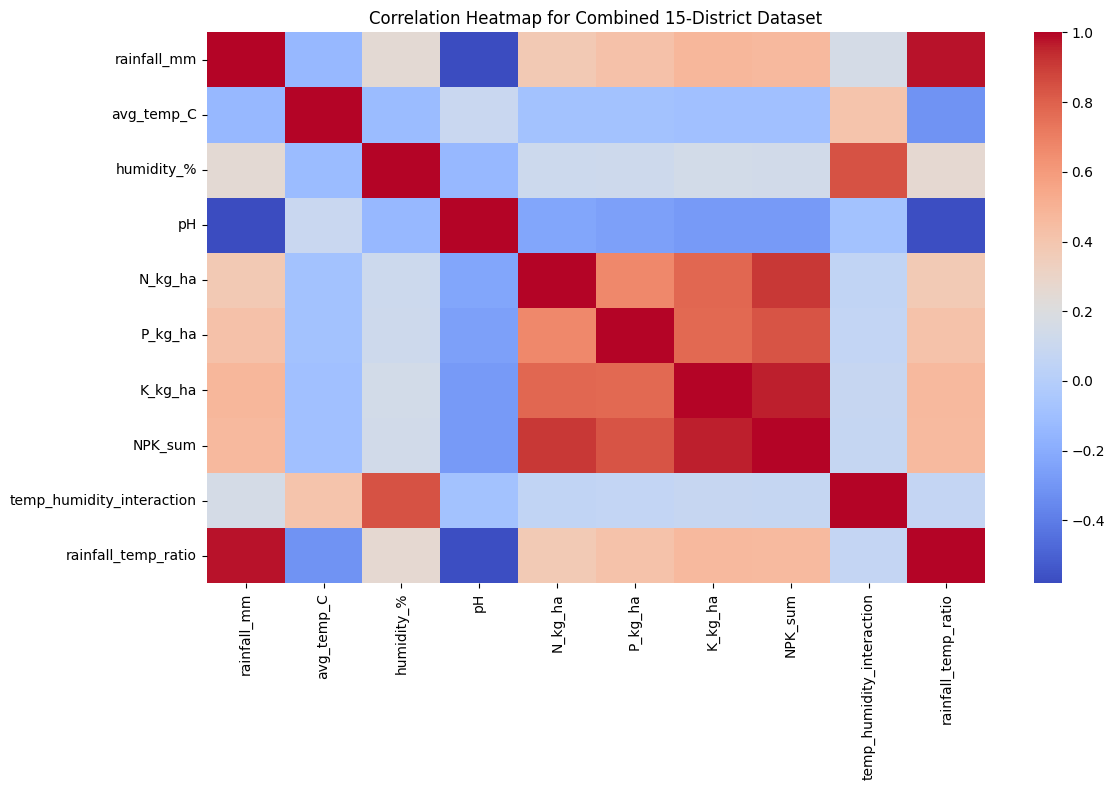


Training RandomForest...
RandomForest Accuracy = 88.60%


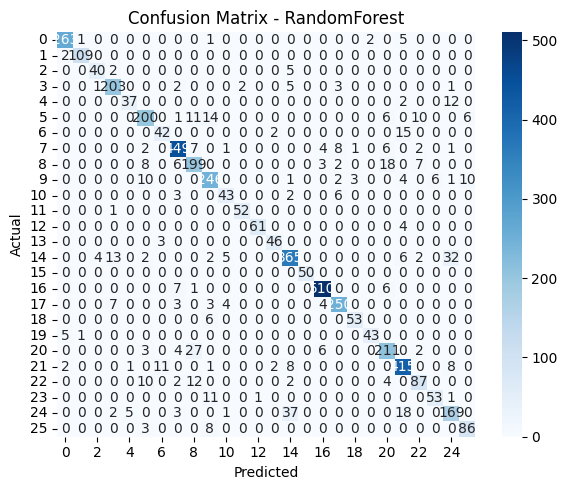


Training XGBoost...
XGBoost Accuracy = 88.72%


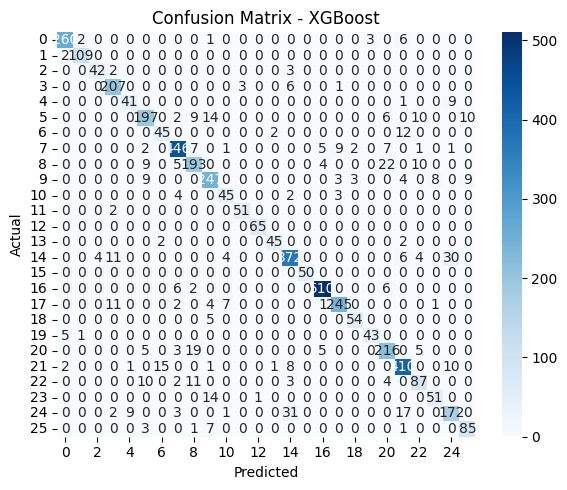


Training CatBoost...
CatBoost Accuracy = 89.01%


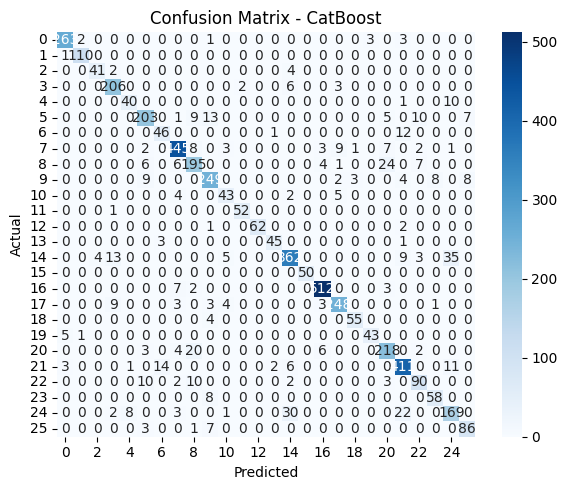


🏆 Best Combined Model: CatBoost
🏆 Accuracy: 89.01%

🎉 All model files & visualizations saved successfully!


In [10]:
# ==================================================================
# BEST ACCURACY SINGLE MODEL FOR 15 DISTRICTS (NO SMOTE)
# Models: CatBoost + XGBoost + RandomForest
# Feature Engineering + Visualizations (FIXED)
# Saves best model + encoders + scaler + graphs
# ==================================================================

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ----------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# Remove unnecessary columns
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 2. Select Only 15 Districts
# ----------------------------------------------------
selected_districts = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag", "Shivamogga", "Ramanagara",
    "Dharwad", "Belagavi", "Hassan", "Mysuru", "Dakshina Kannada",
    "Kalaburagi", "Haveri", "Udupi", "Chitradurga"
]

df = df[df["district"].isin(selected_districts)].reset_index(drop=True)
print("Final dataset size:", len(df))

# ----------------------------------------------------
# 3. VISUALIZATION – District Distribution
# ----------------------------------------------------
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="district")
plt.xticks(rotation=45)
plt.title("Distribution of Samples Across 15 Districts")
plt.tight_layout()
plt.savefig("viz_district_distribution.png")
plt.show()

# ----------------------------------------------------
# 4. Feature Engineering
# ----------------------------------------------------
df["NPK_sum"] = df["N_kg_ha"] + df["P_kg_ha"] + df["K_kg_ha"]
df["temp_humidity_interaction"] = df["avg_temp_C"] * df["humidity_%"]
df["rainfall_temp_ratio"] = df["rainfall_mm"] / (df["avg_temp_C"] + 1)

# ----------------------------------------------------
# 5. VISUALIZATION – CORRELATION HEATMAP (FIXED)
# ----------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])  # Only numeric columns

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap for Combined 15-District Dataset")
plt.tight_layout()
plt.savefig("viz_correlation_heatmap.png")
plt.show()

# ----------------------------------------------------
# 6. Encode categorical columns
# ----------------------------------------------------
le_district = LabelEncoder()
df["district"] = le_district.fit_transform(df["district"])

le_season = LabelEncoder()
df["season"] = le_season.fit_transform(df["season"])

le_crop = LabelEncoder()
df["crop"] = le_crop.fit_transform(df["crop"])

# ----------------------------------------------------
# 7. Split features and target
# ----------------------------------------------------
X = df.drop("crop", axis=1)
y = df["crop"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------
# 8. Train-test split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# 9. Models with Optimized Hyperparameters
# ----------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=0.3,
        reg_lambda=2,
        reg_alpha=1,
        eval_metric="mlogloss"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=600,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        verbose=0
    )
}

scores = {}

# ----------------------------------------------------
# 10. Train + Evaluate Models + Confusion Matrices
# ----------------------------------------------------
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    scores[name] = acc

    print(f"{name} Accuracy = {acc*100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"viz_confusion_matrix_{name}.png")
    plt.show()

# ----------------------------------------------------
# 11. Select Best Model
# ----------------------------------------------------
best_model_name = max(scores, key=scores.get)
best_model = models[best_model_name]

print("\n========================================")
print(f"🏆 Best Combined Model: {best_model_name}")
print(f"🏆 Accuracy: {scores[best_model_name]*100:.2f}%")
print("========================================\n")

# ----------------------------------------------------
# 12. Feature Importance Plot
# ----------------------------------------------------
if best_model_name != "CatBoost":
    importances = best_model.feature_importances_
    features = X.columns

    plt.figure(figsize=(10,7))
    sns.barplot(x=importances, y=features)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.savefig("viz_feature_importance.png")
    plt.show()

# ----------------------------------------------------
# 13. Save Model + Encoders + Scaler
# ----------------------------------------------------
os.makedirs("combined_model_final", exist_ok=True)

joblib.dump(best_model, "combined_model_final/best_model.joblib")
joblib.dump(scaler, "combined_model_final/scaler.pkl")
joblib.dump(le_district, "combined_model_final/district_encoder.pkl")
joblib.dump(le_season, "combined_model_final/season_encoder.pkl")
joblib.dump(le_crop, "combined_model_final/crop_encoder.pkl")
joblib.dump(scores, "combined_model_final/model_scores.pkl")

print("🎉 All model files & visualizations saved successfully!")


In [11]:
# combined_model_with_masking.py
# ==================================================================
# Combined model (15-district) training + district-based masking
# - Feature engineering
# - RandomForest / XGBoost / CatBoost comparison
# - District -> allowed-crops map (from user-provided mapping)
# - Mask predictions to district-allowed crops using prediction probabilities
# - Saves model, encoders, scaler, mapping, visualizations
# ==================================================================

import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -------------------------
# CONFIG / PATHS
# -------------------------
DATA_PATH = "Karnataka_realistic_50k_reordered.csv"   # <-- dataset path
OUT_DIR = "combined_model_masked"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# 1) District -> allowed crops map (use the mapping you provided)
# -------------------------
district_crop_map = {
    "Bagalkote": ["Sugarcane", "Sunflower", "Sorghum", "Cotton", "Pulses", "Groundnut", "Wheat"],
    "Ballari": ["Paddy", "Cotton", "Maize", "Pulses", "Oilseeds", "Onion"],
    "Belagavi": ["Sugarcane", "Groundnut", "Maize", "Pulses", "Arecanut", "Rice"],
    "Bengaluru Urban": ["Vegetables", "Flowers", "Tomato", "Potato", "Cucumber", "Maize"],
    "Bengaluru Rural": ["Ragi", "Maize", "Vegetables", "Tomato", "Groundnut", "Banana"],
    "Bidar": ["Paddy", "Pulses", "Sunflower", "Cotton", "Sorghum"],
    "Chamarajanagar": ["Paddy", "Sugarcane", "Ragi", "Millets", "Coconut"],
    "Chikkaballapur": ["Groundnut", "Ragi", "Millets", "Tomato", "Mango"],
    "Chikkamagaluru": ["Coffee", "Pepper", "Arecanut", "Cardamom", "Banana", "Vegetables"],
    "Chitradurga": ["Maize", "Groundnut", "Cotton", "Sorghum", "Pulses"],
    "Dakshina Kannada": ["Arecanut", "Coconut", "Rubber", "Pepper", "Banana", "Paddy"],
    "Davanagere": ["Cotton", "Maize", "Paddy", "Pulses", "Onion"],
    "Dharwad": ["Jowar", "Maize", "Wheat", "Groundnut", "Pulses"],
    "Gadag": ["Jowar", "Sorghum", "Groundnut", "Cotton", "Pulses"],
    "Hassan": ["Coffee", "Arecanut", "Paddy", "Ragi", "Sugarcane", "Vegetables"],
    "Haveri": ["Cotton", "Pulses", "Jowar", "Groundnut", "Maize"],
    "Kalaburagi": ["Paddy", "Jowar", "Pulses", "Sunflower", "Sugarcane"],
    "Kodagu": ["Coffee", "Pepper", "Cardamom", "Banana", "Arecanut"],
    "Kolar": ["Groundnut", "Ragi", "Paddy", "Millets", "Tomato"],
    "Koppal": ["Paddy", "Cotton", "Maize", "Sorghum", "Pulses"],
    "Mandya": ["Sugarcane", "Paddy", "Ragi", "Vegetables", "Coconut"],
    "Mysuru": ["Paddy", "Sugarcane", "Ragi", "Groundnut", "Vegetables", "Mango"],
    "Raichur": ["Paddy", "Pulses", "Cotton", "Sorghum", "Sunflower"],
    "Ramanagara": ["Ragi", "Tomato", "Mulberry", "Groundnut", "Maize"],
    "Shivamogga": ["Paddy", "Arecanut", "Coconut", "Sugarcane", "Millets", "Vegetables"],
    "Tumakuru": ["Groundnut", "Maize", "Paddy", "Ragi", "Vegetables"],
    "Udupi": ["Paddy", "Coconut", "Arecanut", "Cashew", "Banana"],
    "Uttara Kannada": ["Arecanut", "Coconut", "Cashew", "Paddy", "Spices"],
    "Vijayapura": ["Sorghum", "Pulses", "Sugarcane", "Onion", "Grapes"],
    "Yadgir": ["Paddy", "Sorghum", "Cotton", "Pulses", "Millets"]
}

# Save the map (for backend)
with open(os.path.join(OUT_DIR, "district_crop_map.json"), "w", encoding="utf-8") as f:
    json.dump(district_crop_map, f, indent=4, ensure_ascii=False)


# -------------------------
# 2) Load dataset
# -------------------------
print("Loading dataset:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

# Remove unused columns if present (safe-guard)
for col in ["soil_type", "irrigation", "yield_kg_ha"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# (Optional) If your district naming style differs, unify string case & strip spaces
df["district"] = df["district"].astype(str).str.strip()

# If you only want to use the districts that appear in your map, filter:
available_districts = set(district_crop_map.keys())
df = df[df["district"].isin(available_districts)].reset_index(drop=True)
print("Filtered rows (only districts in mapping):", len(df))
print("Districts used:", sorted(df["district"].unique()))


# -------------------------
# 3) Feature engineering
# -------------------------
df["NPK_sum"] = df["N_kg_ha"] + df["P_kg_ha"] + df["K_kg_ha"]
df["temp_humidity_interaction"] = df["avg_temp_C"] * df["humidity_%"]
df["rainfall_temp_ratio"] = df["rainfall_mm"] / (df["avg_temp_C"] + 1e-6)  # avoid div0

# -------------------------
# 4) Encode categorical columns
# -------------------------
le_district = LabelEncoder()
df["district_enc"] = le_district.fit_transform(df["district"])

le_season = LabelEncoder()
df["season_enc"] = le_season.fit_transform(df["season"].astype(str))

# Keep original crop labels (strings) for mapping; encode target separately
le_crop = LabelEncoder()
df["crop_enc"] = le_crop.fit_transform(df["crop"].astype(str))

# Save encoders later
# -------------------------
# 5) Prepare feature set
# We will use district_enc and season_enc columns (encoded),
# and other numeric cols. Keep a deterministic column order for scaler and inference.
# -------------------------
feature_cols = [
    "district_enc",
    "season_enc",
    "rainfall_mm",
    "avg_temp_C",
    "humidity_%",
    "pH",
    "N_kg_ha",
    "P_kg_ha",
    "K_kg_ha",
    "NPK_sum",
    "temp_humidity_interaction",
    "rainfall_temp_ratio"
]

# If some expected columns are missing due to naming mismatch, adapt automatically:
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing expected columns in dataset: {missing}")

X = df[feature_cols].copy()
y = df["crop_enc"].copy()

# -------------------------
# 6) Scale numeric features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # shape (n_samples, n_features)

# -------------------------
# 7) Train-test split
# -------------------------
X_train, X_test, y_train, y_test, df_train_idx, df_test_idx = train_test_split(
    X_scaled, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# We keep df_test_idx to reference original district / crop for visualizations or debugging
df_test = df.loc[df_test_idx].reset_index(drop=True)

# -------------------------
# 8) Models to compare (optimized-ish)
# -------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=None, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600, learning_rate=0.03, max_depth=8,
        subsample=0.9, colsample_bytree=0.9, gamma=0.3,
        reg_lambda=2, reg_alpha=1, use_label_encoder=False, eval_metric="mlogloss", n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=600, learning_rate=0.03, depth=8, loss_function="MultiClass", verbose=0
    )
}

scores = {}
trained_models = {}

# -------------------------
# 9) Train & evaluate
# -------------------------
for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    scores[name] = acc
    trained_models[name] = model
    print(f"{name} Accuracy = {acc*100:.2f}%")

    # save confusion matrix image
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted (enc)")
    plt.ylabel("Actual (enc)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"confusion_matrix_{name}.png"))
    plt.close()

# -------------------------
# 10) Select best model
# -------------------------
best_name = max(scores, key=scores.get)
best_model = trained_models[best_name]
print("\n" + "="*40)
print(f"Best model: {best_name} with accuracy {scores[best_name]*100:.2f}%")
print("="*40)

# -------------------------
# 11) Save model + artifacts
# -------------------------
joblib.dump(best_model, os.path.join(OUT_DIR, "best_model.joblib"))
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.pkl"))
joblib.dump(le_district, os.path.join(OUT_DIR, "district_encoder.pkl"))
joblib.dump(le_season, os.path.join(OUT_DIR, "season_encoder.pkl"))
joblib.dump(le_crop, os.path.join(OUT_DIR, "crop_encoder.pkl"))
joblib.dump(scores, os.path.join(OUT_DIR, "model_scores.pkl"))

# Already saved district_crop_map above to OUT_DIR/district_crop_map.json

# Also save the feature columns order (important for inference)
with open(os.path.join(OUT_DIR, "feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)

print("Saved model and artifacts to:", OUT_DIR)


# -------------------------
# 12) Masking helper functions (for inference)
# -------------------------
def _decode_crop(enc_label):
    return le_crop.inverse_transform([int(enc_label)])[0]

def _encode_crop(crop_name):
    return int(le_crop.transform([crop_name])[0])

def mask_invalid_crop_for_single(district_name, pred_label_enc, pred_proba, crop_encoder=le_crop):
    """
    district_name: string (exact match to keys in district_crop_map)
    pred_label_enc: predicted encoded label (int)
    pred_proba: 1D array of probabilities for each crop class (length = n_classes)
    Returns: final_crop_name (string) that is allowed in district
    """
    # get allowed crop list for district (strings)
    allowed = district_crop_map.get(district_name, None)
    if allowed is None or len(allowed) == 0:
        # If we don't have mapping, fallback to predicted crop
        return _decode_crop(pred_label_enc)

    # decode predicted crop string
    try:
        pred_crop = _decode_crop(pred_label_enc)
    except Exception:
        pred_crop = None

    # If predicted crop is allowed -> good
    if pred_crop in allowed:
        return pred_crop

    # Otherwise iterate over sorted probabilities and find first allowed crop
    sorted_idx = np.argsort(pred_proba)[::-1]  # indices high -> low
    for idx in sorted_idx:
        try:
            candidate = _decode_crop(idx)
        except Exception:
            continue
        if candidate in allowed:
            return candidate

    # Fallback: return first allowed crop
    return allowed[0]


# -------------------------
# 13) Prediction function for a single sample (masked)
# -------------------------
def predict_single(sample_dict, model=None):
    """
    sample_dict must contain:
      - district (string, exactly one of district_crop_map keys)
      - season (string)
      - rainfall_mm, avg_temp_C, humidity_%, pH, N_kg_ha, P_kg_ha, K_kg_ha (numerical)
    Returns:
      dict with raw prediction, masked prediction, probabilities, used model name
    """
    # required keys / default check
    required = ["district", "season", "rainfall_mm", "avg_temp_C", "humidity_%", "pH", "N_kg_ha", "P_kg_ha", "K_kg_ha"]
    for k in required:
        if k not in sample_dict:
            raise ValueError(f"Missing required input '{k}'")

    # use provided model or best_model trained above
    model_to_use = model if model is not None else best_model

    # copy and build features in same order as feature_cols
    district_raw = sample_dict["district"].strip()
    if district_raw not in district_crop_map:
        raise ValueError(f"District '{district_raw}' not found in district_crop_map. Allowed: {list(district_crop_map.keys())}")

    # encode district and season using saved encoders
    district_enc = le_district.transform([district_raw])[0]
    season_enc = le_season.transform([str(sample_dict["season"])])[0]

    # prepare feature vector
    v = [
        district_enc,
        season_enc,
        float(sample_dict["rainfall_mm"]),
        float(sample_dict["avg_temp_C"]),
        float(sample_dict["humidity_%"]),
        float(sample_dict["pH"]),
        float(sample_dict["N_kg_ha"]),
        float(sample_dict["P_kg_ha"]),
        float(sample_dict["K_kg_ha"]),
    ]

    # engineered features (same formulas used in training)
    N = float(sample_dict["N_kg_ha"])
    P = float(sample_dict["P_kg_ha"])
    K = float(sample_dict["K_kg_ha"])
    temp = float(sample_dict["avg_temp_C"])
    humidity = float(sample_dict["humidity_%"])
    rainfall = float(sample_dict["rainfall_mm"])

    v.append(N + P + K)                              # NPK_sum
    v.append(temp * humidity)                        # temp_humidity_interaction
    v.append(rainfall / (temp + 1e-6))               # rainfall_temp_ratio

    # scale
    X_raw = np.array(v).reshape(1, -1)
    X_scaled = scaler.transform(X_raw)

    # predict
    pred_label_enc = int(model_to_use.predict(X_scaled)[0])
    # get probabilities
    if hasattr(model_to_use, "predict_proba"):
        probs = model_to_use.predict_proba(X_scaled)[0]
    else:
        # fallback: create a pseudo-probability vector (one-hot)
        probs = np.zeros(len(le_crop.classes_))
        probs[pred_label_enc] = 1.0

    # mask invalid crop using district map
    final_crop = mask_invalid_crop_for_single(district_raw, pred_label_enc, probs)

    # return both raw (decoded) and masked results
    raw_pred = _decode_crop(pred_label_enc)
    return {
        "district": district_raw,
        "raw_prediction": raw_pred,
        "masked_prediction": final_crop,
        "probabilities": { _decode_crop(i): float(probs[i]) for i in range(len(probs)) },
        "model": best_name
    }


# -------------------------
# 14) Example usage
# -------------------------
if __name__ == "__main__":
    # Example sample (replace values with a real sample)
    sample = {
        "district": "Mandya",
        "season": "Kharif",           # ensure season values similar to training set
        "rainfall_mm": 500.0,
        "avg_temp_C": 28.0,
        "humidity_%": 70.0,
        "pH": 6.5,
        "N_kg_ha": 80.0,
        "P_kg_ha": 30.0,
        "K_kg_ha": 40.0
    }

    out = predict_single(sample)
    print("Prediction result (example):")
    print(json.dumps(out, indent=2, ensure_ascii=False))


Loading dataset: Karnataka_realistic_50k_reordered.csv
Filtered rows (only districts in mapping): 48297
Districts used: ['Bagalkote', 'Ballari', 'Belagavi', 'Bengaluru Rural', 'Bengaluru Urban', 'Bidar', 'Chamarajanagar', 'Chikkaballapur', 'Chikkamagaluru', 'Chitradurga', 'Dakshina Kannada', 'Davanagere', 'Dharwad', 'Gadag', 'Hassan', 'Haveri', 'Kalaburagi', 'Kodagu', 'Kolar', 'Koppal', 'Mandya', 'Mysuru', 'Raichur', 'Ramanagara', 'Shivamogga', 'Tumakuru', 'Udupi', 'Uttara Kannada', 'Vijayapura', 'Yadgir']

Training RandomForest ...
RandomForest Accuracy = 79.60%

Training XGBoost ...


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [12:33:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy = 81.25%

Training CatBoost ...
CatBoost Accuracy = 81.36%

Best model: CatBoost with accuracy 81.36%
Saved model and artifacts to: combined_model_masked
Prediction result (example):
{
  "district": "Mandya",
  "raw_prediction": "Cotton",
  "masked_prediction": "Paddy",
  "probabilities": {
    "Arecanut": 1.1036829050370051e-05,
    "Banana": 1.4824789134345355e-05,
    "Cardamom": 1.2111124044142172e-05,
    "Cashew": 1.863978929039715e-05,
    "Coconut": 0.007949380315610025,
    "Coffee": 1.6002576424249028e-05,
    "Cotton": 0.8340258220480101,
    "Cucumber": 3.7427471326724305e-05,
    "Flowers": 3.916713240291185e-05,
    "Grapes": 3.776504814928938e-05,
    "Groundnut": 0.0001238802074166109,
    "Jowar": 0.0005972976135120789,
    "Maize": 0.014097868503042746,
    "Mango": 0.0017232097734865988,
    "Millets": 0.00010314616901866787,
    "Mulberry": 2.0489096652129513e-05,
    "Oilseeds": 9.403724454023304e-05,
    "Onion": 0.00017987197704013287,
    "Paddy

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\hp\AppData\Local\Temp\ipykernel_34892\4148573204.py:338: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label_enc = int(model_to_use.predict(X_scaled)[0])


In [2]:
# ==================================================================
# TRAIN SEPARATE MODELS FOR 15 DISTRICTS
# Models: RandomForest + XGBoost
# Saves: Best Model + Encoders + Scaler + Accuracy Summary
# NO VISUALIZATIONS
# ==================================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ----------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# Remove unused columns
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 2. Select ONLY required 15 districts
# ----------------------------------------------------
selected_15 = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag", "Shivamogga", "Ramanagara",
    "Dharwad", "Belagavi", "Hassan", "Mysuru", "Dakshina Kannada",
    "Kalaburagi", "Haveri", "Udupi", "Chitradurga"
]

df = df[df["district"].isin(selected_15)].reset_index(drop=True)
print("Total rows from 15 districts:", len(df))

# ----------------------------------------------------
# 3. Create folder to store models
# ----------------------------------------------------
os.makedirs("models_15districts", exist_ok=True)

results = {}

# ----------------------------------------------------
# 4. Train District-wise Models
# ----------------------------------------------------
for district in selected_15:
    print("\n============================================")
    print(f"TRAINING FOR DISTRICT: {district}")
    print("============================================")

    ddf = df[df["district"] == district].reset_index(drop=True)

    if len(ddf) < 30:
        print(f"⚠ Skipping {district} (not enough data)")
        continue

    # Features and labels
    X = ddf.drop(["crop", "district"], axis=1)
    y = ddf["crop"]

    # Encoders
    le_season = LabelEncoder()
    X["season"] = le_season.fit_transform(X["season"])

    le_crop = LabelEncoder()
    y = le_crop.fit_transform(y)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ML Models
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=20, random_state=42
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.75,
            eval_metric="mlogloss"
        )
    }

    scores = {}

    # Train & Evaluate
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        scores[name] = acc
        print(f"{name} Accuracy = {acc*100:.2f}%")

    # Select best
    best_name = max(scores, key=scores.get)
    best_model = models[best_name]

    print(f"🏆 BEST MODEL for {district}: {best_name}")
    print(f"🏆 Accuracy: {scores[best_name]*100:.2f}%")

    results[district] = {
        "best_model": best_name,
        "accuracy": scores[best_name]
    }

    # Save model + encoders
    joblib.dump(best_model, f"models_15districts/{district}_model.joblib")
    joblib.dump(le_season, f"models_15districts/{district}_season_encoder.pkl")
    joblib.dump(le_crop, f"models_15districts/{district}_crop_encoder.pkl")
    joblib.dump(scaler, f"models_15districts/{district}_scaler.pkl")

# ----------------------------------------------------
# 5. Save summary of accuracies
# ----------------------------------------------------
joblib.dump(results, "models_15districts/accuracy_summary.pkl")

print("\n🎉 COMPLETED TRAINING SEPARATE MODELS FOR 15 DISTRICTS!")
print(results)


Total rows from 15 districts: 24163

TRAINING FOR DISTRICT: Mandya
RandomForest Accuracy = 83.33%
XGBoost Accuracy = 83.63%
🏆 BEST MODEL for Mandya: XGBoost
🏆 Accuracy: 83.63%

TRAINING FOR DISTRICT: Vijayapura
RandomForest Accuracy = 91.51%
XGBoost Accuracy = 90.57%
🏆 BEST MODEL for Vijayapura: RandomForest
🏆 Accuracy: 91.51%

TRAINING FOR DISTRICT: Bagalkote
RandomForest Accuracy = 84.88%
XGBoost Accuracy = 86.11%
🏆 BEST MODEL for Bagalkote: XGBoost
🏆 Accuracy: 86.11%

TRAINING FOR DISTRICT: Gadag
RandomForest Accuracy = 81.65%
XGBoost Accuracy = 79.82%
🏆 BEST MODEL for Gadag: RandomForest
🏆 Accuracy: 81.65%

TRAINING FOR DISTRICT: Shivamogga
RandomForest Accuracy = 89.78%
XGBoost Accuracy = 89.47%
🏆 BEST MODEL for Shivamogga: RandomForest
🏆 Accuracy: 89.78%

TRAINING FOR DISTRICT: Ramanagara
RandomForest Accuracy = 88.57%
XGBoost Accuracy = 87.30%
🏆 BEST MODEL for Ramanagara: RandomForest
🏆 Accuracy: 88.57%

TRAINING FOR DISTRICT: Dharwad
RandomForest Accuracy = 90.45%
XGBoost Accur

In [3]:
# ==================================================================
# SUMMARY: Samples, Classes, Feature Info for Presentation
# ==================================================================

print("\n================ DATASET SUMMARY ================")
print("Total rows after selecting 15 districts:", len(df))

# -----------------------------
# Feature Information
# -----------------------------
features = df.drop(["crop", "district"], axis=1).columns
num_features = len(features)

print("\nFeature Columns Used:")
for f in features:
    print(" -", f)

print("\nTotal Features:", num_features)
print("Target Variable: crop\n")

# -----------------------------
# District-wise Samples + Classes
# -----------------------------
summary = []

for district in selected_15:
    ddf = df[df["district"] == district]

    if len(ddf) == 0:
        continue

    num_samples = len(ddf)
    num_classes = ddf["crop"].nunique()
    class_counts = ddf["crop"].value_counts().to_dict()

    print("\n--------------------------------------------")
    print(f"District: {district}")
    print("--------------------------------------------")
    print("Samples:", num_samples)
    print("Unique Crops:", num_classes)
    print("Crop Distribution:")
    for crop_name, count in class_counts.items():
        print(f"   {crop_name}: {count}")

    summary.append({
        "district": district,
        "samples": num_samples,
        "unique_crops": num_classes,
        "distribution": class_counts
    })




================ DATASET SUMMARY ================
Total rows after selecting 15 districts: 24163

Feature Columns Used:
 - season
 - rainfall_mm
 - avg_temp_C
 - humidity_%
 - pH
 - N_kg_ha
 - P_kg_ha
 - K_kg_ha

Total Features: 8
Target Variable: crop


--------------------------------------------
District: Mandya
--------------------------------------------
Samples: 1679
Unique Crops: 5
Crop Distribution:
   Vegetables: 352
   Sugarcane: 337
   Coconut: 337
   Paddy: 330
   Ragi: 323

--------------------------------------------
District: Vijayapura
--------------------------------------------
Samples: 1587
Unique Crops: 5
Crop Distribution:
   Pulses: 331
   Onion: 320
   Sorghum: 318
   Grapes: 314
   Sugarcane: 304

--------------------------------------------
District: Bagalkote
--------------------------------------------
Samples: 1620
Unique Crops: 7
Crop Distribution:
   Wheat: 255
   Sorghum: 238
   Cotton: 230
   Groundnut: 227
   Pulses: 226
   Sunflower: 225
   Sugarcane:

In [4]:
# Unique crops from all 15 districts
unique_crops = df["crop"].unique()

print("Total Unique Crops:", len(unique_crops))
print("\nList of Unique Crops:")
for c in unique_crops:
    print("-", c)


Total Unique Crops: 26

List of Unique Crops:
- Sugarcane
- Grapes
- Pulses
- Groundnut
- Coconut
- Jowar
- Vegetables
- Mango
- Paddy
- Pepper
- Arecanut
- Ragi
- Cotton
- Maize
- Wheat
- Rice
- Sorghum
- Rubber
- Mulberry
- Tomato
- Sunflower
- Millets
- Coffee
- Cashew
- Onion
- Banana


In [5]:
# ==================================================================
# TRAIN SEPARATE MODELS FOR 15 DISTRICTS
# Models: RandomForest + XGBoost + LightGBM + CatBoost + ExtraTrees
# Saves: Best Model + Encoders + Scaler + Accuracy Summary
# ==================================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ----------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------
df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

# Remove unused columns
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)

# ----------------------------------------------------
# 2. Select ONLY required 15 districts
# ----------------------------------------------------
selected_15 = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag", "Shivamogga", "Ramanagara",
    "Dharwad", "Belagavi", "Hassan", "Mysuru", "Dakshina Kannada",
    "Kalaburagi", "Haveri", "Udupi", "Chitradurga"
]

df = df[df["district"].isin(selected_15)].reset_index(drop=True)
print("Total rows from 15 districts:", len(df))

# ----------------------------------------------------
# 3. Create folder to store models
# ----------------------------------------------------
os.makedirs("models_15districts", exist_ok=True)

results = {}

# ----------------------------------------------------
# 4. Train District-wise Models
# ----------------------------------------------------
for district in selected_15:
    print("\n============================================")
    print(f"TRAINING FOR DISTRICT: {district}")
    print("============================================")

    ddf = df[df["district"] == district].reset_index(drop=True)

    if len(ddf) < 30:
        print(f"⚠ Skipping {district} (not enough data)")
        continue

    # Features and labels
    X = ddf.drop(["crop", "district"], axis=1)
    y = ddf["crop"]

    # Encoders
    le_season = LabelEncoder()
    X["season"] = le_season.fit_transform(X["season"])

    le_crop = LabelEncoder()
    y = le_crop.fit_transform(y)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ML Models (5 models)
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=20, random_state=42
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.75,
            eval_metric="mlogloss"
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31
        ),

        "CatBoost": CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function='MultiClass',
            verbose=0
        ),

        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300,
            max_depth=25,
            random_state=42
        )
    }

    scores = {}

    # Train & Evaluate
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        scores[name] = acc
        print(f"{name} Accuracy = {acc*100:.2f}%")

    # Select best model
    best_name = max(scores, key=scores.get)
    best_model = models[best_name]

    print(f"\n🏆 BEST MODEL for {district}: {best_name}")
    print(f"🏆 Accuracy: {scores[best_name]*100:.2f}%")

    results[district] = {
        "best_model": best_name,
        "accuracy": scores[best_name]
    }

#     # Save model + encoders
#     joblib.dump(best_model, f"models_15districts/{district}_model.joblib")
#     joblib.dump(le_season, f"models_15districts/{district}_season_encoder.pkl")
#     joblib.dump(le_crop, f"models_15districts/{district}_crop_encoder.pkl")
#     joblib.dump(scaler, f"models_15districts/{district}_scaler.pkl")

# # ----------------------------------------------------
# # 5. Save summary of accuracies
# # ----------------------------------------------------
# joblib.dump(results, "models_15districts/accuracy_summary.pkl")

# print("\n🎉 COMPLETED TRAINING SEPARATE MODELS FOR 15 DISTRICTS!")
# print(results)


Total rows from 15 districts: 24163

TRAINING FOR DISTRICT: Mandya
RandomForest Accuracy = 83.33%
XGBoost Accuracy = 83.63%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1613
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 8
[LightGBM] [Info] Start training from score -1.622931
[LightGBM] [Info] Start training from score -1.567872
[LightGBM] [Info] Start training from score -1.657484
[LightGBM] [Info] Start training from score -1.638141
[LightGBM] [Info] Start training from score -1.564307
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy = 83.33%
CatBoost Accuracy = 84.52%
ExtraTrees Accuracy = 83.33%

🏆 BEST MODEL for Mandya: CatBoost
🏆 Accuracy: 84.52%

TRAINING FOR DISTRICT: Vijayapura
RandomForest Accuracy = 91.51%
XGBoost Accuracy = 90.57%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1609
[LightGBM] [Info] Number of data points in the train set: 1269, number of used features: 8
[LightGBM] [Info] Start training from score -1.616555
[LightGBM] [Info] Start training from score -1.600807
[LightGBM] [Info] Start training from score -1.554997
[LightGBM] [Info] Start training from score -1.608650
[LightGBM] [Info] Start training from score -1.669521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy = 89.94%
CatBoost Accuracy = 90.25%
ExtraTrees Accuracy = 91.51%

🏆 BEST MODEL for Vijayapura: RandomForest
🏆 Accuracy: 91.51%

TRAINING FOR DISTRICT: Bagalkote
RandomForest Accuracy = 84.88%
XGBoost Accuracy = 86.11%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1571
[LightGBM] [Info] Number of data points in the train set: 1296, number of used features: 8
[LightGBM] [Info] Start training from score -1.930596
[LightGBM] [Info] Start training from score -1.996554
[LightGBM] [Info] Start training from score -1.941291
[LightGBM] [Info] Start training from score -1.946682
[LightGBM] [Info] Start training from score -2.037139
[LightGBM] [Info] Start training from score -1.974081
[LightGBM] [Info] Start training from score -1.810452
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...

CatBoost Accuracy = 90.24%
ExtraTrees Accuracy = 89.05%

🏆 BEST MODEL for Haveri: RandomForest
🏆 Accuracy: 90.53%

TRAINING FOR DISTRICT: Udupi
RandomForest Accuracy = 96.44%
XGBoost Accuracy = 96.76%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1528
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 8
[LightGBM] [Info] Start training from score -1.631597
[LightGBM] [Info] Start training from score -1.567318
[LightGBM] [Info] Start training from score -1.559566
[LightGBM] [Info] Start training from score -1.656809
[LightGBM] [Info] Start training from score -1.635755
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatBoost Accuracy = 95.79%
ExtraTrees Accuracy = 96.76%

🏆 BEST MODEL for Udupi: LightGBM
🏆 Accuracy: 97.09%

TRAINING FOR DISTRICT: Chitradurga
RandomForest Accuracy = 92.55%
XGBoost Accuracy = 90.68%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 1288, number of used features: 8
[LightGBM] [Info] Start training from score -1.688575
[LightGBM] [Info] Start training from score -1.600164
[LightGBM] [Info] Start training from score -1.639385
[LightGBM] [Info] Start training from score -1.526056
[LightGBM] [Info] Start training from score -1.600164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatBoost Accuracy = 91.61%
ExtraTrees Accuracy = 91.61%

🏆 BEST MODEL for Chitradurga: RandomForest
🏆 Accuracy: 92.55%


In [12]:
# ==================================================================
# TRAIN 15 DISTRICT MODELS + SAVE BEST MODEL + CREATE 4 CANVASES
# ==================================================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -----------------------
# Config
# -----------------------
CSV_PATH = "Karnataka_realistic_50k_reordered.csv"
OUT_DIR = "models_15districts"
os.makedirs(OUT_DIR, exist_ok=True)

selected_15 = [
    "Mandya", "Vijayapura", "Bagalkote", "Gadag",
    "Shivamogga", "Ramanagara", "Dharwad", "Belagavi",
    "Hassan", "Mysuru", "Dakshina Kannada", "Kalaburagi",
    "Haveri", "Udupi", "Chitradurga"
]

RANDOM_STATE = 42
MIN_SAMPLES = 30


# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv(CSV_PATH)
df = df.drop(["soil_type", "irrigation", "yield_kg_ha"], axis=1)
df = df[df["district"].isin(selected_15)].reset_index(drop=True)

print("Total rows after filtering:", len(df))


# -----------------------
# Train best model for a district
# -----------------------
def train_best_for_district(ddf):
    X = ddf.drop(["crop", "district"], axis=1).copy()
    y = ddf["crop"].copy()

    le_season = LabelEncoder()
    X["season"] = le_season.fit_transform(X["season"])

    le_crop = LabelEncoder()
    y_enc = le_crop.fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
    )

    models = {
        "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=20),
        "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                subsample=0.85, colsample_bytree=0.75,
                                use_label_encoder=False, eval_metric="mlogloss"),
        "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05),
        "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05,
                                       depth=6, loss_function='MultiClass', verbose=0),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=300, max_depth=25),
    }

    scores = {}
    fitted = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        scores[name] = acc
        fitted[name] = model
        print(f"  {name}: {acc*100:.2f}%")

    best_name = max(scores, key=scores.get)

    return {
        "best_name": best_name,
        "best_model": fitted[best_name],
        "accuracy": scores[best_name],
        "le_crop": le_crop,
        "le_season": le_season,
        "scaler": scaler,
        "X_test": X_test,
        "y_test": y_test
    }


# -----------------------
# Train + Save Models
# -----------------------
best_info = {}

for district in selected_15:
    ddf = df[df["district"] == district].reset_index(drop=True)
    print(f"\nTraining {district} ({len(ddf)} samples)...")

    if len(ddf) < MIN_SAMPLES:
        print("  Skipped due to insufficient data.")
        continue

    info = train_best_for_district(ddf)
    best_info[district] = info

    print(f"Best for {district}: {info['best_name']} ({info['accuracy']*100:.2f}%)")

    # ---------------------------------
    # SAVE MODEL + ENCODERS + SCALER
    # ---------------------------------
    joblib.dump(info["best_model"], f"{OUT_DIR}/{district}_model.joblib")
    joblib.dump(info["le_crop"], f"{OUT_DIR}/{district}_crop_encoder.pkl")
    joblib.dump(info["le_season"], f"{OUT_DIR}/{district}_season_encoder.pkl")
    joblib.dump(info["scaler"], f"{OUT_DIR}/{district}_scaler.pkl")

    print(f"✔ Saved {district} best model + encoders")


# -----------------------
# Plot 4 districts per canvas
# -----------------------
def plot_4districts_canvas(districts, out_file):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i in range(4):
        ax = axes[i]

        if i >= len(districts):
            ax.axis("off")
            continue

        district = districts[i]
        info = best_info[district]

        model = info["best_model"]
        X_test = info["X_test"]
        y_test = info["y_test"]
        le_crop = info["le_crop"]

        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        labels = le_crop.inverse_transform(np.arange(len(le_crop.classes_)))

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, xticks_rotation=45, include_values=True)

        acc = info["accuracy"] * 100
        ax.set_title(f"{district} — {info['best_name']}\nAccuracy: {acc:.2f}%")

    plt.subplots_adjust(hspace=0.4, wspace=0.35)
    plt.savefig(out_file, bbox_inches="tight", dpi=200)
    plt.close(fig)

    print(f"Saved {out_file}")


# -----------------------
# Group and create canvases
# -----------------------
groups = [selected_15[i:i+4] for i in range(0, len(selected_15), 4)]

while len(groups) < 4:
    groups.append([])

for idx, group in enumerate(groups, start=1):
    out_file = f"{OUT_DIR}/confusion_canvas_{idx}.png"
    print(f"\nGenerating canvas {idx} → {group}")
    plot_4districts_canvas(group, out_file)

print("\n🎉 ALL MODELS SAVED + ALL CANVASES GENERATED SUCCESSFULLY!")


Total rows after filtering: 24163

Training Mandya (1679 samples)...
  RandomForest: 83.93%


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [18:32:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost: 83.93%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 8
[LightGBM] [Info] Start training from score -1.604239
[LightGBM] [Info] Start training from score -1.626712
[LightGBM] [Info] Start training from score -1.649702
[LightGBM] [Info] Start training from score -1.604239
[LightGBM] [Info] Start training from score -1.564307
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM: 84.52%
  CatBoost: 83.93%
  ExtraTrees: 84.52%
Best for Mandya: LightGBM (84.52%)
✔ Saved Mandya best model + encoders

Training Vijayapura (1587 samples)...
  RandomForest: 92.14%


...

  XGBoost: 93.48%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 1288, number of used features: 8
[LightGBM] [Info] Start training from score -1.692786
[LightGBM] [Info] Start training from score -1.588692
[LightGBM] [Info] Start training from score -1.639385
[LightGBM] [Info] Start training from score -1.511872
[LightGBM] [Info] Start training from score -1.623512
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CatBoost: 91.61%
  ExtraTrees: 94.41%
Best for Chitradurga: ExtraTrees (94.41%)
✔ Saved Chitradurga best model + encoders

Generating canvas 1 → ['Mandya', 'Vijayapura', 'Bagalkote', 'Gadag']


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved models_15districts/confusion_canvas_1.png

Generating canvas 2 → ['Shivamogga', 'Ramanagara', 'Dharwad', 'Belagavi']
Saved models_15districts/confusion_canvas_2.png

Generating canvas 3 → ['Hassan', 'Mysuru', 'Dakshina Kannada', 'Kalaburagi']
Saved models_15districts/confusion_canvas_3.png

Generating canvas 4 → ['Haveri', 'Udupi', 'Chitradurga']
Saved models_15districts/confusion_canvas_4.png

🎉 ALL MODELS SAVED + ALL CANVASES GENERATED SUCCESSFULLY!


In [13]:
import pandas as pd

df = pd.read_csv("Karnataka_realistic_50k_reordered.csv")

print("Unique Seasons:", df["season"].unique())
print("Total Unique Seasons:", df["season"].nunique())


Unique Seasons: ['Kharif' 'Rabi' 'Summer' 'Year-round']
Total Unique Seasons: 4
